# Crop Quality Filter Diagnostic
This notebook helps you understand how the offline refinement (Stage A) filters crops.

**Usage:**
1. Set the `CROP_FOLDER` path to a person folder (e.g., `outputs/step2_global_crops_fixed/person_001`).
2. (Optional) Override any threshold from `config.py`.
3. Run all cells. You will see:
   - Histograms of sharpness, area ratio, aspect ratio, width, height.
   - Samples of crops that pass / fail each filter.
   - Summary counts.

In [57]:
# ========== EDIT THESE ==========
CROP_FOLDER = "outputs/test3/refined_v1/person_016" #transparent_run/step2_crops/person_001"   # path to a person folder
# test later for test3/refined/person_016

# Reference frame size for area ratio calculation (use the original camera resolution)
FRAME_WIDTH  = 1280   # change to your video width
FRAME_HEIGHT = 720    # change to your video height

# Override any config thresholds (set to None to use config.py values)
# These match the offline refinement Stage A filters.
MIN_SHARPNESS        = None   # e.g., 12.0
MIN_AREA_RATIO       = None   # e.g., 0.0012
MAX_ASPECT_RATIO     = 5.0   # e.g., 3.5 (set 0 to disable)
MIN_WIDTH            = None   # e.g., 10
MIN_HEIGHT           = None   # e.g., 20
# ==================================

In [51]:
import sys, os
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

from pathlib import Path
import sys, os

# Option A: point directly to the reid_system folder
project_root = Path.cwd() / "reid_system"
if not (project_root / "config.py").exists():
    # If you ran the notebook from reid_system/experiments
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

# Use overrides or config defaults
MIN_SHARPNESS = config.REFINE_MIN_REID_SHARPNESS if MIN_SHARPNESS is None else MIN_SHARPNESS
MIN_AREA_RATIO = config.REFINE_MIN_REID_AREA_RATIO if MIN_AREA_RATIO is None else MIN_AREA_RATIO
MAX_ASPECT_RATIO = config.REFINE_MAX_ASPECT_RATIO if MAX_ASPECT_RATIO is None else MAX_ASPECT_RATIO
MIN_WIDTH = config.MIN_REID_WIDTH if MIN_WIDTH is None else MIN_WIDTH
MIN_HEIGHT = config.MIN_REID_HEIGHT if MIN_HEIGHT is None else MIN_HEIGHT

print("Current filter thresholds:")
print(f"  Sharpness (Laplacian var) >= {MIN_SHARPNESS}")
print(f"  Area ratio (bbox area / frame area) >= {MIN_AREA_RATIO:.4f}")
print(f"  Aspect ratio max <= {MAX_ASPECT_RATIO} (0=disabled)")
print(f"  Minimum width >= {MIN_WIDTH}")
print(f"  Minimum height >= {MIN_HEIGHT}")
print(f"  Reference frame: {FRAME_WIDTH}x{FRAME_HEIGHT}")

Current filter thresholds:
  Sharpness (Laplacian var) >= 12.0
  Area ratio (bbox area / frame area) >= 0.0012
  Aspect ratio max <= 5.0 (0=disabled)
  Minimum width >= 10
  Minimum height >= 20
  Reference frame: 1280x720


In [52]:
folder = Path(CROP_FOLDER)
if not folder.is_absolute():
    # Allow paths relative to project_root when running from reid_system/experiments
    candidate = project_root / folder
    if candidate.exists():
        folder = candidate
if not folder.exists():
    raise FileNotFoundError(f"Folder not found: {folder}")

# Gather all image paths
img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
img_paths = sorted([p for p in folder.iterdir() if p.suffix.lower() in img_exts])
print(f"Found {len(img_paths)} images in {folder.name}")

Found 18 images in samples


In [53]:
# Compute metrics for every crop
metrics = []
for p in img_paths:
    img = cv2.imread(str(p))
    if img is None:
        continue
    h, w = img.shape[:2]
    # Sharpness
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sharp = cv2.Laplacian(gray, cv2.CV_32F).var()
    # Area ratio (using the crop size as the bbox, since we don't have original bbox)
    area_ratio = (w * h) / (FRAME_WIDTH * FRAME_HEIGHT)
    # Aspect ratio (max dimension / min dimension)
    aspect = max(w, h) / max(1, min(w, h))
    metrics.append({
        "path": p,
        "w": w,
        "h": h,
        "sharpness": sharp,
        "area_ratio": area_ratio,
        "aspect_ratio": aspect,
        "img": img    # keep for display
    })

print(f"Valid images: {len(metrics)}")

# Determine pass/fail for each filter
def check_filters(m):
    status = {
        "width_ok": m["w"] >= MIN_WIDTH,
        "height_ok": m["h"] >= MIN_HEIGHT,
        "area_ratio_ok": m["area_ratio"] >= MIN_AREA_RATIO,
        "sharpness_ok": m["sharpness"] >= MIN_SHARPNESS,
        "aspect_ok": True if MAX_ASPECT_RATIO == 0 else m["aspect_ratio"] <= MAX_ASPECT_RATIO,
    }
    # overall pass
    status["overall"] = all(status.values())
    return status

for m in metrics:
    m["status"] = check_filters(m)

# Summary
passed = sum(1 for m in metrics if m["status"]["overall"])
failed = len(metrics) - passed
print(f"Passed: {passed}, Failed: {failed}")
for filt in ["width_ok", "height_ok", "area_ratio_ok", "sharpness_ok", "aspect_ok"]:
    ok = sum(1 for m in metrics if m["status"][filt])
    print(f"  {filt}: {ok} passed, {len(metrics)-ok} failed")

Valid images: 18
Passed: 18, Failed: 0
  width_ok: 18 passed, 0 failed
  height_ok: 18 passed, 0 failed
  area_ratio_ok: 18 passed, 0 failed
  sharpness_ok: 18 passed, 0 failed
  aspect_ok: 18 passed, 0 failed


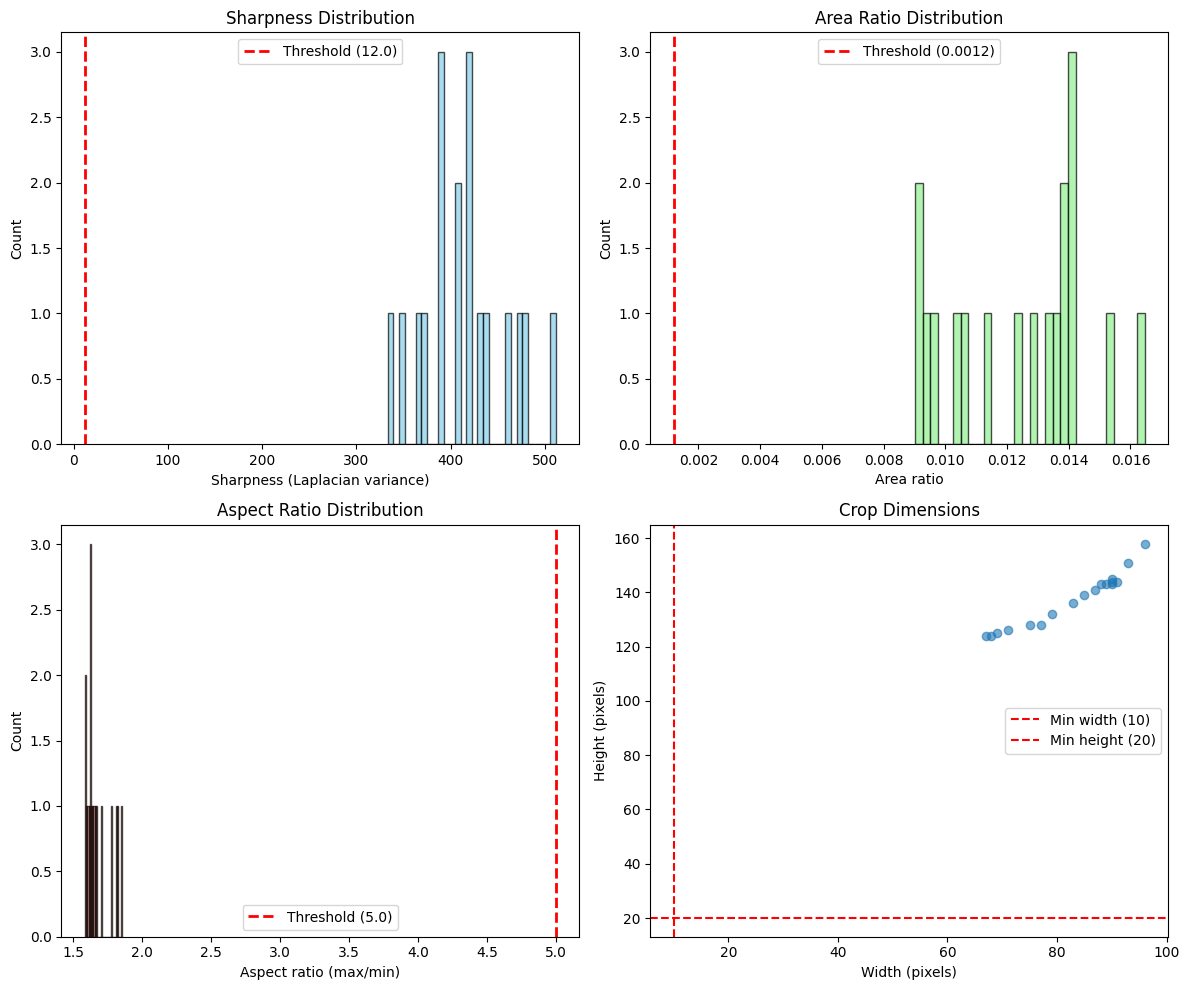

In [54]:
# Histograms of the metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sharpness
ax = axes[0,0]
sharps = [m["sharpness"] for m in metrics]
ax.hist(sharps, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(MIN_SHARPNESS, color='red', linestyle='--', linewidth=2, label=f'Threshold ({MIN_SHARPNESS})')
ax.set_xlabel('Sharpness (Laplacian variance)')
ax.set_ylabel('Count')
ax.set_title('Sharpness Distribution')
ax.legend()

# Area ratio
ax = axes[0,1]
areas = [m["area_ratio"] for m in metrics]
ax.hist(areas, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(MIN_AREA_RATIO, color='red', linestyle='--', linewidth=2, label=f'Threshold ({MIN_AREA_RATIO:.4f})')
ax.set_xlabel('Area ratio')
ax.set_ylabel('Count')
ax.set_title('Area Ratio Distribution')
ax.legend()

# Aspect ratio
ax = axes[1,0]
aspects = [m["aspect_ratio"] for m in metrics]
ax.hist(aspects, bins=30, color='salmon', edgecolor='black', alpha=0.7)
if MAX_ASPECT_RATIO > 0:
    ax.axvline(MAX_ASPECT_RATIO, color='red', linestyle='--', linewidth=2, label=f'Threshold ({MAX_ASPECT_RATIO})')
ax.set_xlabel('Aspect ratio (max/min)')
ax.set_ylabel('Count')
ax.set_title('Aspect Ratio Distribution')
ax.legend()

# Width vs Height scatter
ax = axes[1,1]
ws = [m["w"] for m in metrics]
hs = [m["h"] for m in metrics]
ax.scatter(ws, hs, alpha=0.6)
ax.axvline(MIN_WIDTH, color='red', linestyle='--', label=f'Min width ({MIN_WIDTH})')
ax.axhline(MIN_HEIGHT, color='red', linestyle='--', label=f'Min height ({MIN_HEIGHT})')
ax.set_xlabel('Width (pixels)')
ax.set_ylabel('Height (pixels)')
ax.set_title('Crop Dimensions')
ax.legend()

plt.tight_layout()
plt.show()

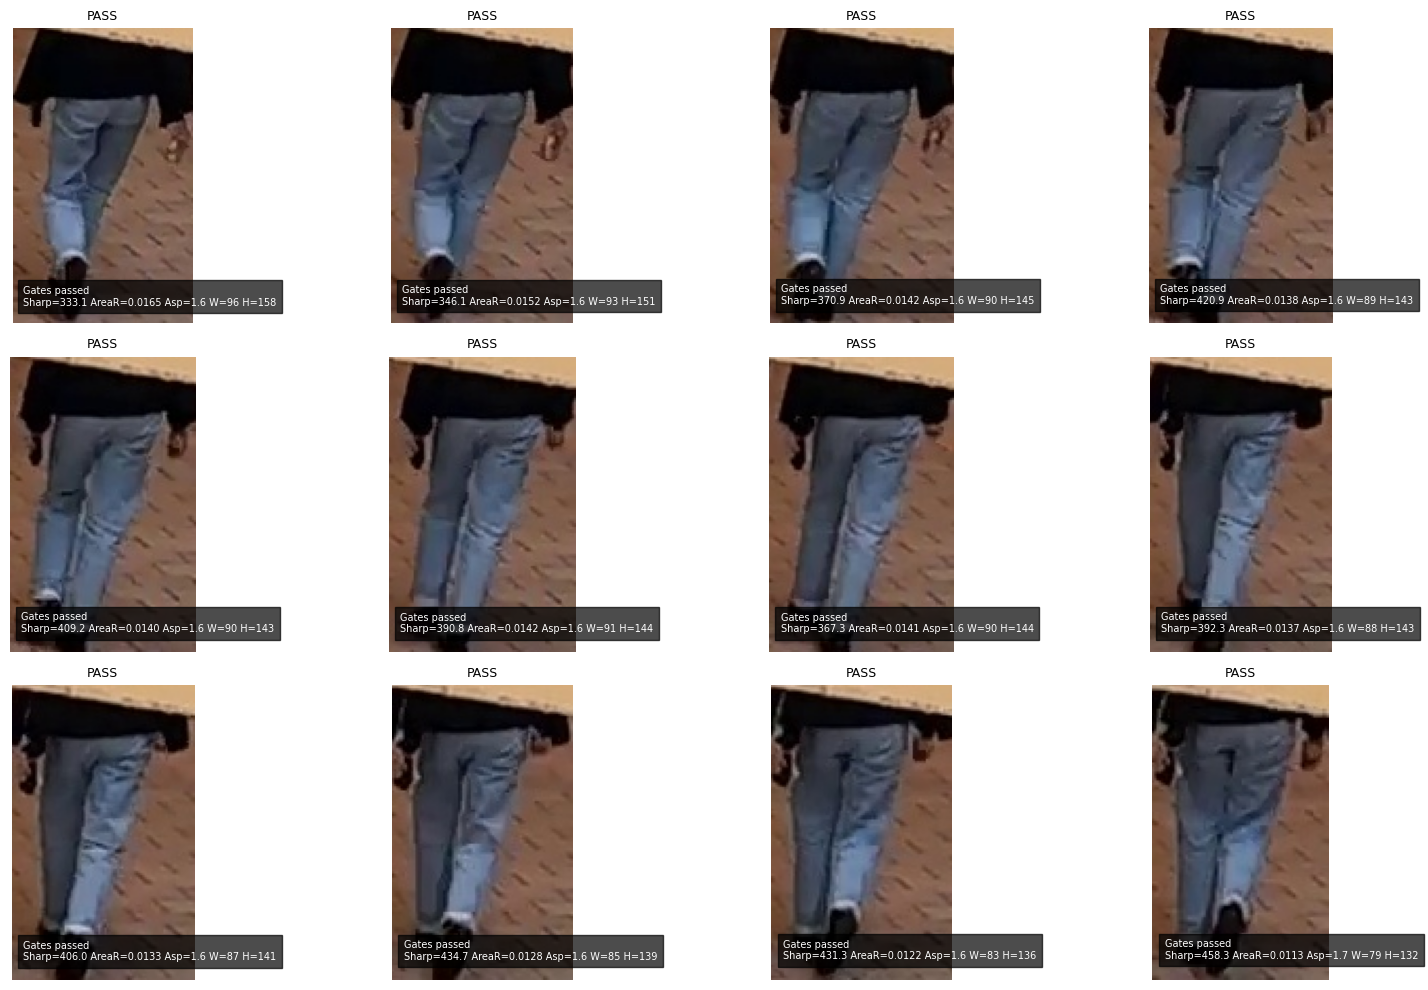

In [55]:
# Show example crops: worst (failing) and best (passing) for each filter
# We'll pick a few examples for each failing filter and display them with metrics

def display_crop(ax, img, title, metrics_text):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    ax.text(5, img.shape[0]-10, metrics_text, fontsize=7, color='white',
            bbox=dict(facecolor='black', alpha=0.7))

# Find crops that fail a specific filter (up to 3 examples per filter)
filter_names = {
    "width_ok": f"Width < {MIN_WIDTH}",
    "height_ok": f"Height < {MIN_HEIGHT}",
    "area_ratio_ok": f"Area ratio < {MIN_AREA_RATIO:.4f}",
    "sharpness_ok": f"Sharpness < {MIN_SHARPNESS}",
    "aspect_ok": f"Aspect ratio > {MAX_ASPECT_RATIO}" if MAX_ASPECT_RATIO>0 else None,
}

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
idx = 0

for filt, description in filter_names.items():
    if description is None:
        continue
    failing = [m for m in metrics if not m["status"][filt]]
    if not failing:
        continue
    # Show up to 2 failing examples
    for m in failing[:2]:
        if idx >= len(axes):
            break
        info = f"{description}\nSharp={m['sharpness']:.1f} AreaR={m['area_ratio']:.4f} Asp={m['aspect_ratio']:.1f} W={m['w']} H={m['h']}"
        display_crop(axes[idx], m["img"], f"FAIL: {description}", info)
        idx += 1

# Now show some passing examples (overall pass)
passing = [m for m in metrics if m["status"]["overall"]]
for m in passing[:max(0, 12-idx)]:
    if idx >= len(axes):
        break
    info = f"Gates passed\nSharp={m['sharpness']:.1f} AreaR={m['area_ratio']:.4f} Asp={m['aspect_ratio']:.1f} W={m['w']} H={m['h']}"
    display_crop(axes[idx], m["img"], "PASS", info)
    idx += 1

# Hide unused axes
for j in range(idx, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

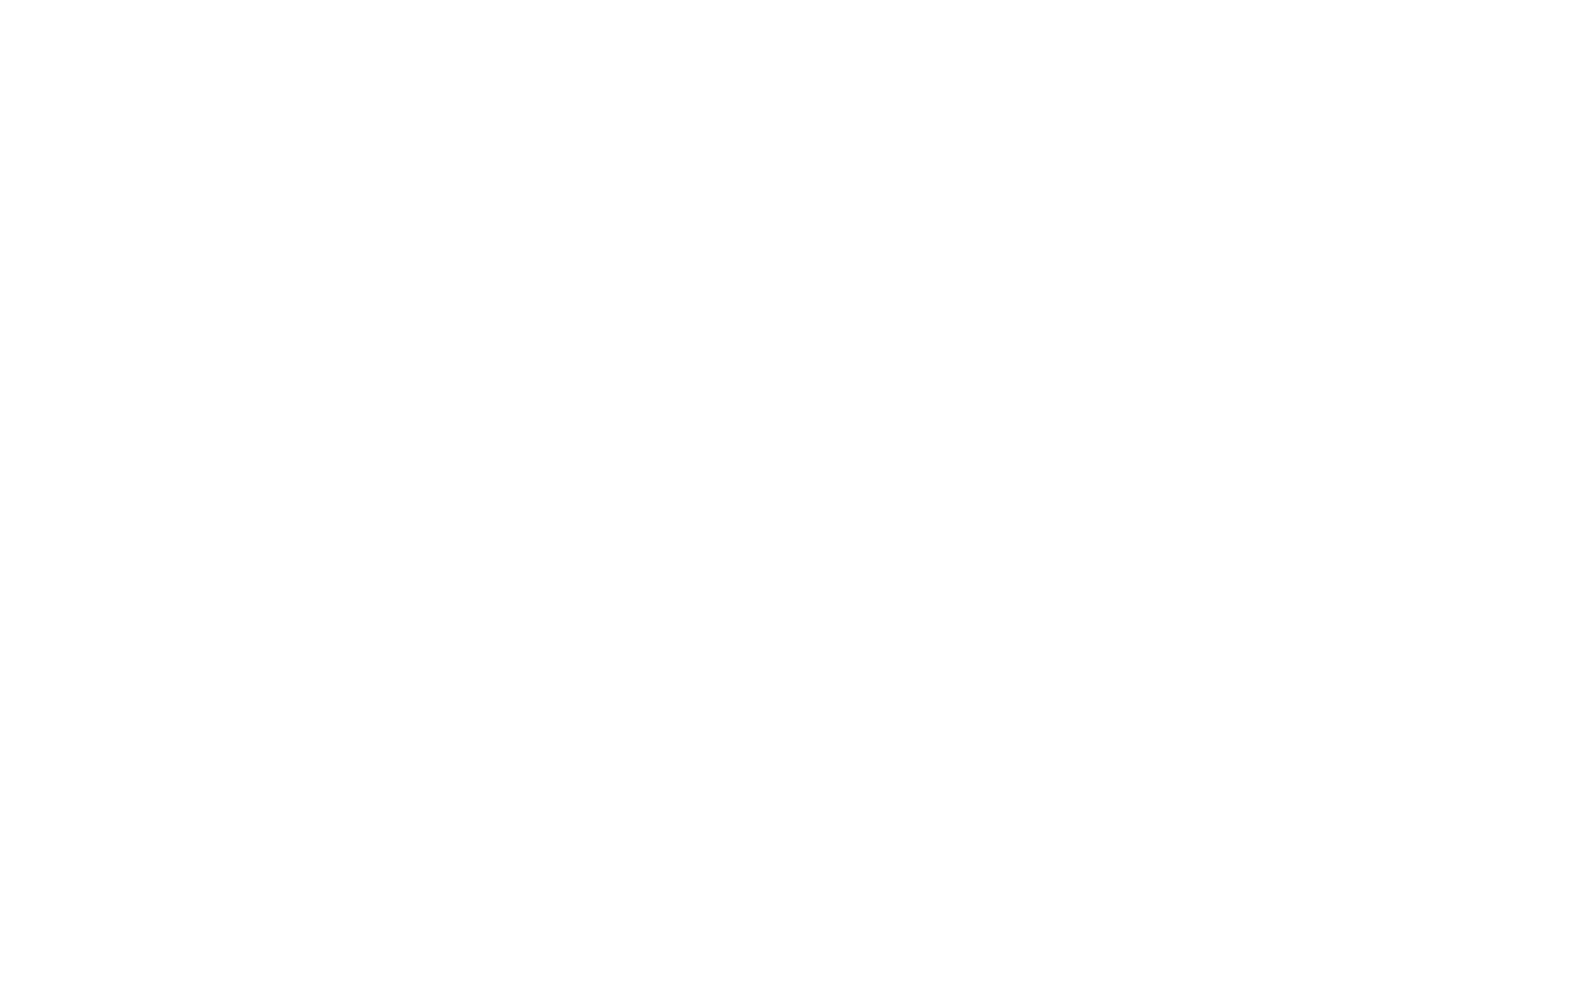

In [56]:
# Show only failed crops
failed = [m for m in metrics if not m["status"]["overall"]]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, m in enumerate(failed[:len(axes)]):
    failed_filters = [name for name, ok in m["status"].items() if name != "overall" and not ok]
    desc = ", ".join(failed_filters)
    info = (
        f"{desc}\n"
        f"Sharp={m['sharpness']:.1f} AreaR={m['area_ratio']:.4f} "
        f"Asp={m['aspect_ratio']:.1f} W={m['w']} H={m['h']}"
    )
    display_crop(axes[i], m["img"], "FAIL", info)

for j in range(len(failed), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Observations
- The histogram red lines show the current thresholds.
- Failed crops are displayed with the exact values that caused rejection.
- You can adjust the override values in the first cell and re‑run to see how the filter changes.